In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import librosa 
import librosa.display


In [3]:
df = pd.read_csv("ESC-50/meta/esc50.csv")
print(df.shape)
df.head()

(2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [4]:
animals = ["cat", "dog", "cow", "sheep", "frog"]

animal_df = df[df["category"].isin(animals)].copy()

print("toplam ses", len(animal_df))
print()
print(animal_df["category"].value_counts())

toplam ses 200

category
dog      40
sheep    40
frog     40
cow      40
cat      40
Name: count, dtype: int64


In [5]:
sample = animal_df[animal_df["category"]=="cat"].iloc[0]

audio_path = "ESC-50/audio/" + sample["filename"]

y, sr = librosa.load(audio_path)

print("Dosya:", sample["filename"])
print("Sample rate:", sr)
print("Süre:", len(y)/sr)

Dosya: 1-34094-A-5.wav
Sample rate: 22050
Süre: 5.0


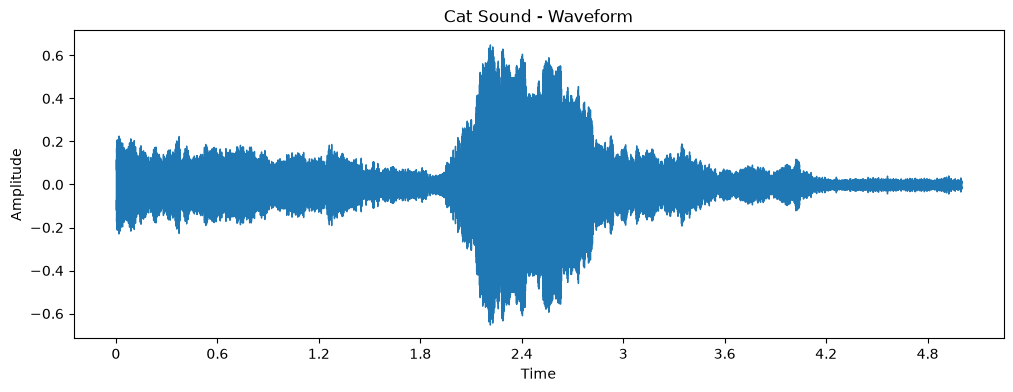

In [6]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(y,sr=sr)

plt.title("Cat Sound - Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

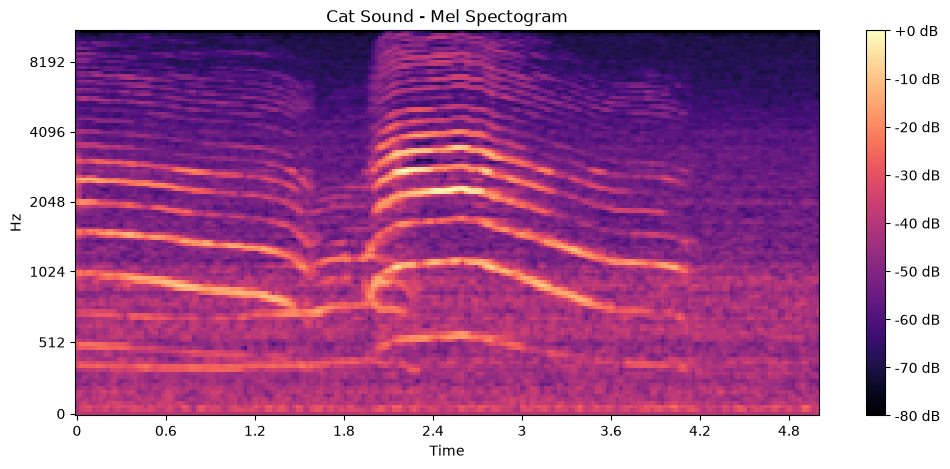

In [7]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Cat Sound - Mel Spectogram")

plt.show()

In [8]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 216)


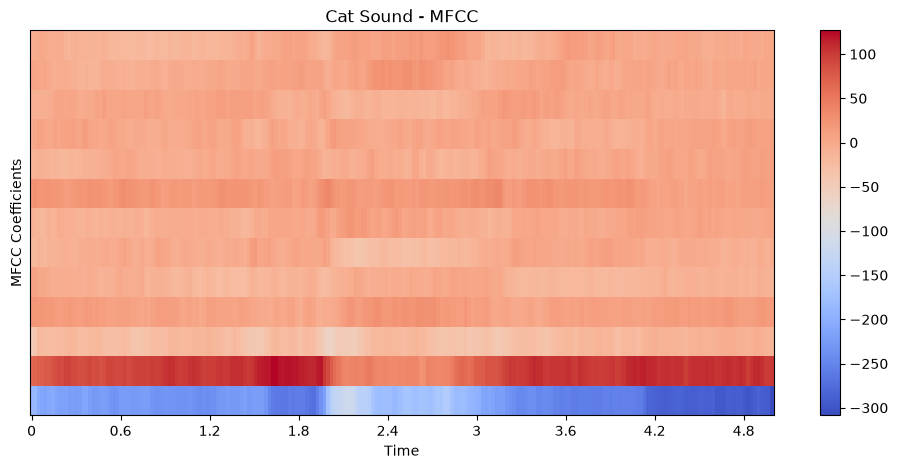

In [9]:
plt.figure(figsize=(12,5))
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)
plt.colorbar()
plt.title("Cat Sound - MFCC")
plt.ylabel("MFCC Coefficients")
plt.show()

In [10]:
mfcc_mean = np.mean(mfcc, axis=1)
mfcc_std = np.std(mfcc, axis=1)

features = np.concatenate([mfcc_mean, mfcc_std])

print("Feature sayısı:", len(features))
print(features)

Feature sayısı: 26
[-2.3104568e+02  9.0094910e+01 -2.4125017e+01  1.1180412e+01
 -1.0237476e+01 -6.0536156e+00 -2.3852122e-01  1.8167515e+01
 -1.0347549e+00  1.3477644e+00  1.0888995e-01  3.1162534e+00
 -2.0825915e+00  4.3016247e+01  2.5638201e+01  1.1054219e+01
  7.2325530e+00  7.8841667e+00  1.1086520e+01  7.9715238e+00
  6.6089153e+00  7.2447038e+00  6.5202622e+00  8.2809725e+00
  8.7827587e+00  1.0844630e+01]


In [11]:
from pathlib import Path

audio_dir = Path("ESC-50/audio")

print(audio_dir.exists())

True


In [12]:
features_list = []

for _, row in animal_df.iterrows():
    audio_path = audio_dir / row["filename"]

    try:
        y, sr = librosa.load(audio_path)

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=13
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        features_list.append({
            "filename": row["filename"],
            "label": row["category"],
            "fold": row["fold"],
            **{f"mfcc_{i+1}_mean": mfcc_mean[i] for i in range(13)},
            **{f"mfcc_{i+1}_std": mfcc_std[i] for i in range(13)}
        })

    except Exception as e:
        print("Hata veren dosya:", audio_path)
        print("Hata:", e)
        break

features_df = pd.DataFrame(features_list)

print("Dataset shape:", features_df.shape)
features_df.head()

Dataset shape: (200, 29)


,filename,label,fold,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,...,mfcc_4_std,mfcc_5_std,mfcc_6_std,mfcc_7_std,mfcc_8_std,mfcc_9_std,mfcc_10_std,mfcc_11_std,mfcc_12_std,mfcc_13_std
0,1-100032-A-0.wav,dog,1,-600.940186,4.694291,-8.505940,-4.276621,-0.818615,-1.973445,-0.294606,...,15.667681,4.175003,8.797460,1.894691,3.545652,3.575997,2.788473,2.427339,1.331945,3.628063
1,1-110389-A-0.wav,dog,1,-586.231384,10.243309,-2.999349,-2.870357,-0.164017,0.698542,-1.224443,...,13.227572,5.150697,2.656182,6.296750,1.463683,3.144939,3.578278,3.720267,3.500848,5.774907
2,1-121951-A-8.wav,sheep,1,-498.421051,123.427841,-17.572025,28.883457,2.824133,10.670028,6.844957,...,15.981906,13.109461,10.958723,16.075108,11.005792,6.103108,6.255210,6.968021,8.325636,5.399708
3,1-15689-A-4.wav,frog,1,-390.902130,26.158421,-33.765991,9.771124,17.299381,10.612135,1.707500,...,11.818456,10.297581,6.104028,6.538595,15.935493,8.870636,6.737124,15.189213,6.201154,4.375620
4,1-15689-B-4.wav,frog,1,-397.259247,40.127975,-25.931139,17.110033,21.223946,16.094236,3.398273,...,7.802856,9.578989,5.830626,6.758957,15.363527,9.608010,6.027559,13.613379,5.069485,3.683304


In [13]:
X = features_df.drop(columns = ["filename","label","fold"])
y = features_df["label"]

In [14]:
train_mask = features_df["fold"] != 1
test_mask = features_df["fold"] == 1

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (160, 26)
Test: (40, 26)


In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test,y_pred))
print()
print(classification_report(y_test,y_pred))


Accuracy: 0.625

              precision    recall  f1-score   support

         cat       0.45      0.62      0.53         8
         cow       0.62      0.62      0.62         8
         dog       0.60      0.38      0.46         8
        frog       1.00      0.75      0.86         8
       sheep       0.60      0.75      0.67         8

    accuracy                           0.62        40
   macro avg       0.66      0.62      0.63        40
weighted avg       0.66      0.62      0.63        40



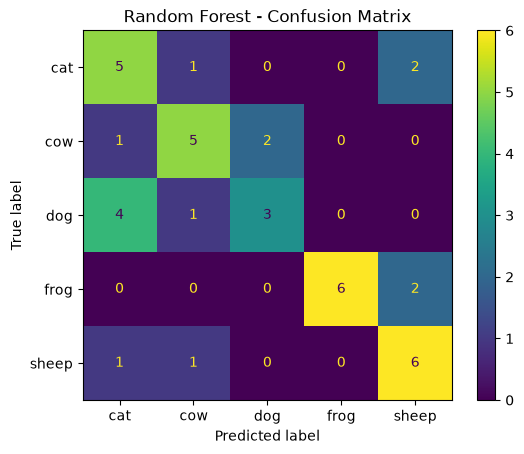

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

X = features_df.drop(columns=["filename", "label", "fold"])
y = features_df["label"]

fold_results = []

for test_fold in range(1, 6):

    train_mask = features_df["fold"] != test_fold
    test_mask = features_df["fold"] == test_fold

    X_train = X[train_mask]
    X_test = X[test_mask]

    y_train = y[train_mask]
    y_test = y[test_mask]

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    fold_results.append(accuracy)

    print(f"Fold {test_fold}: {accuracy:.3f}")

print("\n--------------------")
print(f"Mean Accuracy: {np.mean(fold_results):.3f}")
print(f"Std: {np.std(fold_results):.3f}")

Fold 1: 0.625
Fold 2: 0.725
Fold 3: 0.700
Fold 4: 0.600
Fold 5: 0.600

--------------------
Mean Accuracy: 0.650
Std: 0.052


In [20]:
def extract_features(audio_path):
    y,sr = librosa.load(audio_path)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc,axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    delta = librosa.feature.delta(mfcc)
    delta_mean = np.mean(delta, axis=1)
    delta_std = np.std(delta, axis=1)

    chroma =librosa.feature.chroma_stft(y=y,sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)

    features = np.concatenate([
        mfcc_mean,
        mfcc_std,
        delta_mean,
        delta_std,
        chroma_mean,
        chroma_std,
        [
            np.mean(centroid), np.std(centroid),
            np.mean(bandwidth), np.std(bandwidth),
            np.mean(rolloff), np.std(rolloff),
            np.mean(zcr), np.std(zcr)
        ]
    ])

    return features

In [21]:
sample_path = audio_dir / animal_df.iloc[0]["filename"]
test_features = extract_features(sample_path)
print("yeni feature sayısı:", len(test_features))

yeni feature sayısı: 84


In [23]:
enhanced_features = []

for _, row in animal_df.iterrows():
    audio_path = audio_dir / row["filename"]

    features = extract_features(audio_path)

    enhanced_features.append({
        "filename": row["filename"],
        "label": row["category"],
        "fold": row["fold"],
        **{f"feature_{i+1}": features[i] for i in range(len(features))}
    })

enhanced_df = pd.DataFrame(enhanced_features)

print("Dataset shape:", enhanced_df.shape)
enhanced_df.head()

Dataset shape: (200, 87)


,filename,label,fold,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84
0,1-100032-A-0.wav,dog,1,-600.940186,4.694291,-8.505940,-4.276621,-0.818615,-1.973445,-0.294606,...,0.094359,0.097384,217.341861,724.638970,177.268135,571.592206,328.530884,1164.630248,0.013197,0.042461
1,1-110389-A-0.wav,dog,1,-586.231384,10.243309,-2.999349,-2.870357,-0.164017,0.698542,-1.224443,...,0.169264,0.190079,161.061537,519.052903,210.327197,580.347343,275.744629,949.814718,0.006879,0.025165
2,1-121951-A-8.wav,sheep,1,-498.421051,123.427841,-17.572025,28.883457,2.824133,10.670028,6.844957,...,0.253148,0.236345,1118.027353,562.243513,1678.700356,210.814831,2105.767822,916.012360,0.038841,0.063527
3,1-15689-A-4.wav,frog,1,-390.902130,26.158421,-33.765991,9.771124,17.299381,10.612135,1.707500,...,0.301849,0.246208,3195.685641,493.389614,2792.195629,747.625294,6485.581462,2030.734802,0.101495,0.056519
4,1-15689-B-4.wav,frog,1,-397.259247,40.127975,-25.931139,17.110033,21.223946,16.094236,3.398273,...,0.268217,0.265546,3065.739575,475.336358,2746.055105,893.414824,6343.173218,2197.762895,0.113905,0.050138


In [24]:
X_enhanced = enhanced_df.drop(
    columns = ["filename","label","fold"]
)

y_enhanced = enhanced_df["label"]
print(X_enhanced.shape)

(200, 84)


In [26]:
enhanced_fold_results = []

for test_fold in range(1, 6):

    train_mask = enhanced_df["fold"] != test_fold
    test_mask = enhanced_df["fold"] == test_fold

    X_train = X_enhanced[train_mask]
    X_test = X_enhanced[test_mask]

    y_train = y_enhanced[train_mask]
    y_test = y_enhanced[test_mask]

    model_enhanced = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model_enhanced.fit(X_train, y_train)

    y_pred = model_enhanced.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    enhanced_fold_results.append(accuracy)

    print(f"Fold {test_fold}: {accuracy:.3f}")

print("\n--------------------")
print(f"Mean Accuracy: {np.mean(enhanced_fold_results):.3f}")
print(f"Std: {np.std(enhanced_fold_results):.3f}")

Fold 1: 0.750
Fold 2: 0.750
Fold 3: 0.800
Fold 4: 0.775
Fold 5: 0.625

--------------------
Mean Accuracy: 0.740
Std: 0.060


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_fold_results = []

for test_fold in range(1, 6):

    train_mask = enhanced_df["fold"] != test_fold
    test_mask = enhanced_df["fold"] == test_fold

    X_train = X_enhanced[train_mask]
    X_test = X_enhanced[test_mask]

    y_train = y_enhanced[train_mask]
    y_test = y_enhanced[test_mask]

    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=10,
            gamma="scale"
        ))
    ])

    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    svm_fold_results.append(accuracy)

    print(f"Fold {test_fold}: {accuracy:.3f}")

print("\n--------------------")
print(f"Mean Accuracy: {np.mean(svm_fold_results):.3f}")
print(f"Std: {np.std(svm_fold_results):.3f}")

Fold 1: 0.725
Fold 2: 0.675
Fold 3: 0.725
Fold 4: 0.825
Fold 5: 0.625

--------------------
Mean Accuracy: 0.715
Std: 0.066


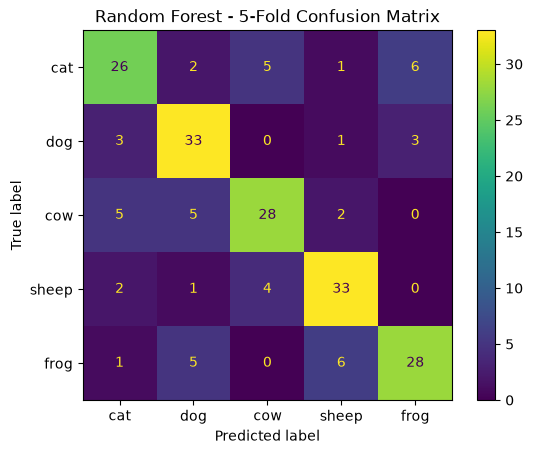

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_true = []
all_pred = []

for test_fold in range(1, 6):

    train_mask = enhanced_df["fold"] != test_fold
    test_mask = enhanced_df["fold"] == test_fold

    X_train = X_enhanced[train_mask]
    X_test = X_enhanced[test_mask]

    y_train = y_enhanced[train_mask]
    y_test = y_enhanced[test_mask]

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

labels = ["cat", "dog", "cow", "sheep", "frog"]

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Random Forest - 5-Fold Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_true,
        all_pred,
        labels=["cat", "dog", "cow", "sheep", "frog"]
    )
)


              precision    recall  f1-score   support

         cat       0.70      0.65      0.68        40
         dog       0.72      0.82      0.77        40
         cow       0.76      0.70      0.73        40
       sheep       0.77      0.82      0.80        40
        frog       0.76      0.70      0.73        40

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

